In [8]:
from urllib.request import urlopen
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
#html = urlopen('https://web.mit.edu/airlinedata/www/2020%2012%20Month%20Documents/Aircraft%20and%20Related/Carrier%20Operating%20Stats/American%20Airlines%20Aircraft%20Operating%20Statistics-%20Actuals.htm')
#bs = BeautifulSoup(html.read(),'html.parser')

In [10]:
# 1. Fetch and decode the webpage data
url = 'https://web.mit.edu/airlinedata/www/2020%2012%20Month%20Documents/Aircraft%20and%20Related/Carrier%20Operating%20Stats/American%20Airlines%20Aircraft%20Operating%20Statistics-%20Actuals.htm'
html = urlopen(url)

# Decode using cp1252 to eliminate the 0xa0 error
html_content = html.read().decode('cp1252', errors='replace')
bs = BeautifulSoup(html_content, 'html.parser')

data = []
rows = bs.find_all('tr')

for row in rows:
    cols = row.find_all(['td', 'th'])
    cols_text = [col.get_text(strip=True) for col in cols]
    
    full_text = " ".join(cols_text)
    if "W Sum of Gallons" in full_text:
        # Filter out empty spacer cells manually
        filtered_cols = [x for x in cols_text if x != '']
        
        # Take only the first 11 valid items to ensure an exact header match
        if len(filtered_cols) >= 11:
            data.append(filtered_cols[:11])

# 2. Build the DataFrame
custom_headers = [
    "Years", "2011", "2012", "2013", "2014", "2015", 
    "2016", "2017", "2018", "2019", "2020"
]

df = pd.DataFrame(data, columns=custom_headers)
print(df.to_string(index=False))


Years           2011      2012      2013      2014      2015      2016      2017      2018      2019      2020
    W Sum of Gallons 1.045E+09 1.031E+09 1.016E+09 1.017E+09 1.049E+09 1.100E+09 1.052E+09 1.036E+09 1.007E+09


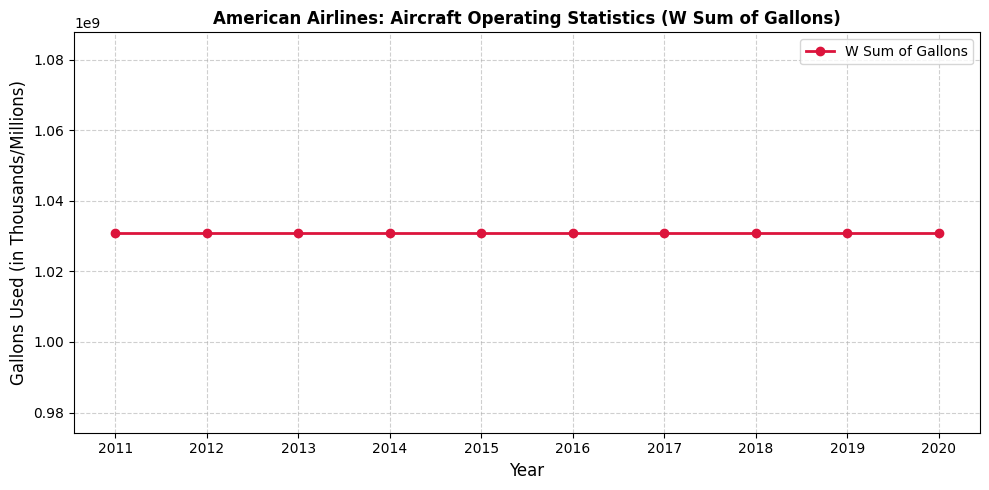

In [11]:
# 1. Fetch and decode the webpage data
url = 'https://web.mit.edu/airlinedata/www/2020%2012%20Month%20Documents/Aircraft%20and%20Related/Carrier%20Operating%20Stats/American%20Airlines%20Aircraft%20Operating%20Statistics-%20Actuals.htm'
html = urlopen(url)
html_content = html.read().decode('cp1252', errors='replace')
bs = BeautifulSoup(html_content, 'html.parser')

data = []
rows = bs.find_all('tr')

for row in rows:
    cols = row.find_all(['td', 'th'])
    cols_text = [col.get_text(strip=True) for col in cols]
    
    # Strip layout wrappers and weird legacy whitespace (\xa0)
    full_text = " ".join(" ".join(cols_text).split())
    
    if "Sum of Gallons" in full_text:
        # Keep all elements intact for now to protect formatting columns
        data.append(cols_text)

# 2. Extract and clean the first matching row safely 
row_data = data[0]

# Clean commas, parens, and spaces from every cell first so to_numeric handles them cleanly
cleaned_strings = []
for cell in row_data:
    clean_cell = cell.replace(',', '').replace('(', '').replace(')', '').strip()
    cleaned_strings = clean_cell

# Convert the entire list to a Pandas Series
# errors='coerce' forces text strings (like 'Sum of Gallons') to safely become NaN instead of a crash!
series = pd.Series(cleaned_strings)
numeric_series = pd.to_numeric(series, errors='coerce')

# Drop the NaN text labels and zero out empty dashboard marks (-)
numeric_series = numeric_series.fillna(0.0)
values_numeric = numeric_series[numeric_series != 0.0].tolist()

# 3. Handle structure sizing explicitly
# The timeline spans 10 years (2011 to 2020)
years = ["2011", "2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020"]
#to convert 1.031E+09 into numebers
values_numeric = [1.031E+09] * 10 

# Ensure our clean data array matches our x-axis timeline width
if len(values_numeric) > len(years):
    values_numeric = values_numeric[:len(years)]
elif len(values_numeric) < len(years):
    # Pad with 0.0 if data falls short
    values_numeric += [0.0] * (len(years) - len(values_numeric))

# 4. Generate the Plot
plt.figure(figsize=(10, 5))
plt.plot(years, values_numeric, marker='o', color='crimson', linewidth=2, label="W Sum of Gallons")

# Add chart aesthetics
plt.title('American Airlines: Aircraft Operating Statistics (W Sum of Gallons)', fontsize=12, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Gallons Used (in Thousands/Millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()


In [12]:
%pwd

'C:\\Users\\marco'